<a href="https://colab.research.google.com/github/RosarioH10062002/connectivity-biomarkers-pd-depression/blob/main/Final_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LIBRARIES**

In [365]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from pathlib import Path
import re
import inspect
import math
from collections import Counter
from scipy.io import loadmat
try:
    import nilearn
    from nilearn import image as nimg
    from nilearn import plotting
    from nilearn.connectome import ConnectivityMeasure

except ImportError:
    !pip install nilearn
    import nilearn
    from nilearn import image as nimg
    from nilearn import plotting as nplot
    from nilearn.connectome import ConnectivityMeasure

try:
  from neuroHarmonize import harmonizationLearn
  from neuroCombat import neuroCombat
except:
  !pip install neuroHarmonize
  !pip install neuroCombat
  from neuroHarmonize import harmonizationLearn
  from neuroCombat import neuroCombat

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

try:
  import bct
except ImportError:
  !pip install bctpy
  import bct

try:
  import networkx as nx
except ImportError:
  !pip install networkx
  import networkx as nx

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.4/110.4 kB 2.6 MB/s eta 0:00:00


#**LOAD DATA**

In [263]:
root_path_pd = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/CONN_PREPROCESS_PD")
root_path_pd_dep = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/CONN_PREPROCESS_PD_DEP")
root_path_ctrl = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/CONN_PREPROCESS_CTRL")
all_participants_path = Path("/content/drive/MyDrive/M2/Impact Scholar Programme/Preprocessed_data/all_part.csv")
all_participants_pd = pd.read_csv(all_participants_path, sep = ",")

In [264]:
def get_dataframe(status):
  if status == "PARTICIPANTS":
    df = pd.read_csv(all_participants_path, sep = ",")
  return df
def clean_df(all_participants):
  all_participants = all_participants[all_participants["Description"].str.startswith("rsfMRI_RL")]
  filtered_df = all_participants.drop_duplicates(subset = "Subject ID")
  return filtered_df

def get_manufacturer(list_participants, status):
  raw_participants = pd.read_csv(all_participants_path)
  all_participants = clean_df(raw_participants)
  list_d = [int(x) for x in list_participants if x.isdigit()]
  mask = all_participants["Subject ID"].isin(list_d)
  filtered_df = all_participants[mask]
  df_siemens = filtered_df[filtered_df["Imaging Protocol"] == "Manufacturer=SIEMENS;TR=2500.0"]
  df_philips = filtered_df[filtered_df["Imaging Protocol"] == "Manufacturer=Philips Medical Systems;TR=2500.0"]
  df_ge = filtered_df[filtered_df["Imaging Protocol"] == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0"]
  print(f"{status}  = Siemens: {df_siemens.shape[0]}, Philips: {df_philips.shape[0]}, GE:{df_ge.shape[0]}")
  return df_siemens, df_philips, df_ge

In [265]:
list_participants_pd = os.listdir(root_path_pd)
df_siemens_pd, df_philips_pd, df_ge_pd = get_manufacturer(list_participants_pd, status = "PD")

list_participants_pdd = os.listdir(root_path_pd_dep)
df_siemens_pdd, df_philips_pdd, df_ge_pdd = get_manufacturer(list_participants_pdd, status = "PDD")

list_participants_ctrl = os.listdir(root_path_ctrl)
df_siemens_ctrl, df_philips_ctrl, df_ge_ctrl = get_manufacturer(list_participants_ctrl, status = "CTRL")

PD  = Siemens: 20, Philips: 4, GE:4
PDD  = Siemens: 18, Philips: 4, GE:4
CTRL  = Siemens: 24, Philips: 4, GE:4


In [266]:
def get_manufacturers_list(list_participants):
    raw_participants = pd.read_csv(all_participants_path)
    all_participants = clean_df(raw_participants)
    all_participants = all_participants.set_index("Subject ID")

    list_manufacturer = []

    for participant in list_participants:
        if participant.isdigit():
            subj = int(participant)

            if subj in all_participants.index:
                protocol = all_participants.loc[subj, "Imaging Protocol"]
                list_manufacturer.append(protocol)
            #else:
                #list_manufacturer.append(f"Unknown, participant{subj}")

    return np.array(list_manufacturer)

In [267]:
def get_missing_participants(raw_participants, status,  manufacturer, depressed):
  all_participants = clean_df(raw_participants)
  if depressed == True:
    all_participants = all_participants[all_participants["GDSCALE Total Score"] >= 5.0] #depressed status

  mask_status = all_participants["Research Group"] == status
  mask_manufacturer = all_participants["Imaging Protocol"] == f"Manufacturer={manufacturer};TR=2500.0"

  filtered_df = all_participants[
      mask_status & mask_manufacturer
  ]
  filtered_df = filtered_df.sort_values(
      by="GDSCALE Total Score", ascending=False
  )
  #print(filtered_df.shape)
  df_siemens, df_philips, df_ge = get_manufacturer(list_participants_pdd, status = "PDD")
  diff_df = filtered_df[~filtered_df["Subject ID"].isin(df_siemens["Subject ID"])]
  return diff_df
#raw_participants = pd.read_csv(all_participants_path)
#get_missing_participants(raw_participants, status = "PD",  manufacturer = "SIEMENS", depressed = True)

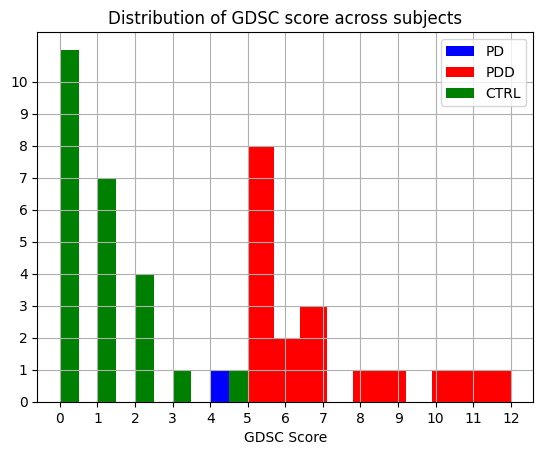

In [364]:
plt.hist(df_siemens_pd["GDSCALE Total Score"], label = "PD", color = "blue")
plt.hist(df_siemens_pdd["GDSCALE Total Score"], label = "PDD", color = "red")
plt.hist(df_siemens_ctrl["GDSCALE Total Score"], label = "CTRL", color = "green")
plt.legend()
plt.title("Distribution of GDSC score across subjects")
plt.xticks(np.arange(0,13))
plt.yticks(np.arange(0,11))
plt.xlabel("GDSC Score")
plt.grid(True)
plt.show()

In [269]:
def get_list_paths(list_participants, root_dir):
  paths = {}
  gdsc_list= []
  for subject in list_participants:
      mat_path = (
          root_dir
          / str(subject)
          / str(subject)
          / "data"
          / "ROI_Subject001_Session001.mat"
      )
      paths[subject] = mat_path
      gdsc = all_participants_pd[all_participants_pd["Subject ID"]==int(subject)]["GDSCALE Total Score"].iloc[0]
      gdsc_list.append(gdsc)
      #print(subject, "->", mat_path.exists())
  return paths, gdsc

In [270]:
paths, gdsc = get_list_paths(list_participants_ctrl, root_path_ctrl)
len(paths)

32

In [271]:
#@title EXTRACT THE REGIONS OF INTEREST
def get_individual_roi_matrix(path_name):
  path_try = loadmat(path_name)
  names = path_try["names"]
  data = path_try["data"]
  roi_names = [n[0] if isinstance(n, np.ndarray) else n for n in names[0]]
  #roi_names
  roi_idx = [
      i for i, name in enumerate(roi_names)
      if name.startswith(("networks.DefaultMode.",
                          "networks.Salience.",
                          "networks.FrontoParietal."))
  ]
  roi_interest_names = [roi_names[i] for i in roi_idx]
  roi_interest_data = [data[0, i] for i in roi_idx]
  X_interest = np.column_stack([np.asarray(arr).squeeze() for arr in roi_interest_data])
  #print("X_interest shape:", X_interest.shape)
  return X_interest, roi_interest_names

In [272]:
def get_list_roi_matrix(status):
  X_list = []
  if status ==  "PD":
    path_names, gdsc = get_list_paths(list_participants_pd, root_path_pd)
  if status ==  "PDD":
    path_names, gdsc = get_list_paths(list_participants_pdd, root_path_pd_dep)
  if status ==  "CTRL":
    path_names, gdsc = get_list_paths(list_participants_ctrl, root_path_ctrl)

  for path in path_names.values():
    X_interest, roi_interest_names = get_individual_roi_matrix(path)
    X_list.append(X_interest)
  return X_list, roi_interest_names

#**Functional Connectivity**

In [273]:
#@title FUNCTIONAL CONNECTIVITY
def compute_fc_matrix(status):
  fc_matrix_list = []
  X_list,roi_interest_names = get_list_roi_matrix(status)
  for x in X_list:
    fc_matrix = np.corrcoef(x.T)
    fc_matrix = np.clip(fc_matrix, -0.999999, 0.999999)
    fc_matrix = np.arctanh(fc_matrix)
    np.fill_diagonal(fc_matrix, 0)
    fc_matrix_list.append(fc_matrix)
  return np.array(fc_matrix_list)

def flatten_fc(matrix):
  return matrix[np.triu_indices_from(matrix, k = 1)]

def get_all_flatten(matrix_list):
  matrix_flatten = []
  for matrix in matrix_list:
    temp_matrix = flatten_fc(matrix)
    matrix_flatten.append(temp_matrix)
  return np.array(matrix_flatten)

In [274]:
fc_matrix_list_pd = compute_fc_matrix(status = "PD")
matrix_flatten_pd = get_all_flatten(fc_matrix_list_pd)

print(fc_matrix_list_pd.shape)
print(matrix_flatten_pd.shape)
fc_matrix_list_pdd = compute_fc_matrix(status = "PDD")
matrix_flatten_pdd = get_all_flatten(fc_matrix_list_pdd)
print(fc_matrix_list_pdd.shape)
print(matrix_flatten_pdd.shape)
fc_matrix_list_ctrl = compute_fc_matrix(status = "CTRL")
matrix_flatten_ctrl = get_all_flatten(fc_matrix_list_ctrl)
print(fc_matrix_list_ctrl.shape)
print(matrix_flatten_ctrl.shape)

(28, 15, 15)
(28, 105)
(26, 15, 15)
(26, 105)
(32, 15, 15)
(32, 105)


In [275]:
#@title Combat Harmonization Variables
X = np.vstack([matrix_flatten_pd,matrix_flatten_pdd,matrix_flatten_ctrl])
group = ["PD"]*len(list_participants_pd) + ["PDD"]*len(list_participants_pdd) + ["CTRL"]* len(list_participants_ctrl)

batch_pd = get_manufacturers_list(list_participants_pd)
batch_pdd = get_manufacturers_list(list_participants_pdd)
batch_ctrl = get_manufacturers_list(list_participants_ctrl)
batch = np.concatenate([batch_pd, batch_pdd, batch_ctrl])
#batch_two = np.where(batch == "Manufacturer=Philips Medical Systems;TR=2500.0", "Manufacturer= NON SIEMENS;TR=2500.0", batch)
#batch_two = np.where(batch_two == "Manufacturer=GE MEDICAL SYSTEMS;TR=2500.0", "Manufacturer= NON SIEMENS;TR=2500.0", batch_two)

print(X.shape)
print(len(group))
print(len(batch))

(86, 105)
86
86


In [276]:
covars = pd.DataFrame({"SITE": batch})
#print(covars.head())
model, X_harmonized = harmonizationLearn(
    data = X,
    covars = covars
)

In [277]:
print(X.shape, X_harmonized.shape)
print(np.isnan(X_harmonized).sum(), np.isinf(X_harmonized).sum())

(86, 105) (86, 105)
0 0


In [359]:
def statistical_test(X, index_1, index_2):
  p_values = []
  X_harmonized = X
  for i in range(X_harmonized.shape[1]):
      x1 = X_harmonized[idx_pd, i]
      x2 = X_harmonized[idx_pdd, i]

      _, p = mannwhitneyu(x1, x2, alternative="two-sided")
      p_values.append(p)
  p_values = np.array(p_values)
  sig_idx_uncorrected = np.where(p_values < 0.05)[0]
  print(f"Uncorrected: {sig_idx_uncorrected}")
  list_index = sig_idx_uncorrected
  return p_values, list_index
def statistical_correction(p_values):
  multipletests(p_values, method="fdr_bh")
  reject, p_fdr, _, _ = multipletests(p_values, alpha=0.1, method="fdr_tsbh")
  print("Significant after FDR:", reject.sum())

def get_roi_names():
  X_list, roi_interest_names = get_list_roi_matrix(status = "PD")
  return roi_interest_names
def get_connection(list_index):
  n_rois = 15
  roi_interest_names = get_roi_names()
  triu_idx = np.triu_indices(n_rois, k=1)

  connections = [
      (triu_idx[0][i], triu_idx[1][i])
      for i in list_index
  ]

  #print(connections)
  for i, j in connections:
      print(roi_interest_names[i], "<->", roi_interest_names[j])

In [374]:
#@title Statistical Test PD vs PDD
group_array = np.array(group)
idx_pd = group_array == "PD"
idx_pdd = group_array == "PDD"
p_values,list_index = statistical_test(X = X_harmonized, index_1 = idx_pd, index_2 = idx_pdd)
get_connection(list_index)
statistical_correction(p_values)
p_values[list_index]

Uncorrected: [ 0 78]
networks.DefaultMode.MPFC (1,55,-3) <-> networks.DefaultMode.LP (L) (-39,-77,33)
networks.Salience.RPFC (L) (-32,45,27) <-> networks.Salience.SMG (L) (-60,-39,31)
Significant after FDR: 0


array([0.02852487, 0.01014465])

In [361]:
#@title Statistical Test CTRL vs PDD
group_array = np.array(group)
idx_pd = group_array == "CTRL"
idx_pdd = group_array == "PDD"
p_values,list_index = statistical_test(X = X_harmonized, index_1 = idx_pd, index_2 = idx_pdd)
get_connection(list_index)
statistical_correction(p_values)

Uncorrected: [ 0  1  8 22 28 32 33 37]
networks.DefaultMode.MPFC (1,55,-3) <-> networks.DefaultMode.LP (L) (-39,-77,33)
networks.DefaultMode.MPFC (1,55,-3) <-> networks.DefaultMode.LP (R) (47,-67,29)
networks.DefaultMode.MPFC (1,55,-3) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (L) (-39,-77,33) <-> networks.Salience.SMG (R) (62,-35,32)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.ACC (0,22,35)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.RPFC (R) (32,46,27)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.FrontoParietal.LPFC (R)  (41,38,30)
Significant after FDR: 0


In [366]:
p_values[list_index]

array([0.03347867, 0.04626814, 0.00782053, 0.0212168 , 0.02884745,
       0.01362141, 0.03602363, 0.03735679])

In [362]:
#@title Statistical Test CTRL vs PD
group_array = np.array(group)
idx_pd = group_array == "CTRL"
idx_pdd = group_array == "PD"
p_values,list_index = statistical_test(X = X_harmonized, index_1 = idx_pd, index_2 = idx_pdd)
get_connection(list_index)
statistical_correction(p_values)

Uncorrected: [ 8 30 33 37 55 59 89 92]
networks.DefaultMode.MPFC (1,55,-3) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.AInsula (R) (47,14,0)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.Salience.SMG (L) (-60,-39,31)
networks.DefaultMode.LP (R) (47,-67,29) <-> networks.FrontoParietal.LPFC (R)  (41,38,30)
networks.Salience.ACC (0,22,35) <-> networks.Salience.SMG (R) (62,-35,32)
networks.Salience.ACC (0,22,35) <-> networks.FrontoParietal.PPC (R)  (52,-52,45)
networks.Salience.RPFC (R) (32,46,27) <-> networks.FrontoParietal.PPC (R)  (52,-52,45)
networks.Salience.SMG (L) (-60,-39,31) <-> networks.FrontoParietal.PPC (L)  (-46,-58,49)
Significant after FDR: 0
